# Brent Oil Price Analysis
# Task 1 - Exploratory Data Analysis


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss

In [2]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

In [3]:
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


### Dataset Preview

The first five rows of the dataset show that it contains daily Brent crude oil prices beginning on **20 May 1987**. Each record consists of a date and the corresponding Brent oil price (USD per barrel). The dataset appears to be chronologically ordered and suitable for time series analysis.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


### Data Structure

The dataset contains **9,011 observations** and **2 variables**:

- **Date:** Stored as a datetime object (`datetime64`), making it suitable for time series operations.
- **Price:** Stored as a floating-point number representing the daily Brent crude oil price in USD per barrel.

No missing values are present in either column, indicating that the dataset is complete and requires no missing-value treatment before analysis.

In [6]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


### Summary Statistics

The Brent oil prices exhibit substantial variation over the study period.

Key observations include:

- Total observations: **9,011**
- Mean price: **48.42 USD/barrel**
- Median price: **38.57 USD/barrel**
- Minimum price: **9.10 USD/barrel**
- Maximum price: **143.95 USD/barrel**
- Standard deviation: **32.86 USD/barrel**

The large standard deviation relative to the mean indicates considerable price volatility over time, suggesting the influence of major economic and geopolitical events.

In [7]:
df.shape

(9011, 2)

### Dataset Dimensions

The dataset contains **9,011 rows** and **2 columns**, providing over three decades of daily Brent oil price observations for analysis.

In [8]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

### Missing Value Assessment

No missing values were detected in the dataset.

Since both the Date and Price columns are complete, no imputation or data cleaning related to missing observations is required.

In [9]:
df.duplicated().sum()

np.int64(0)

### Duplicate Record Assessment

No duplicate records were identified in the dataset.

This indicates that each observation represents a unique trading day and no duplicate removal is necessary.

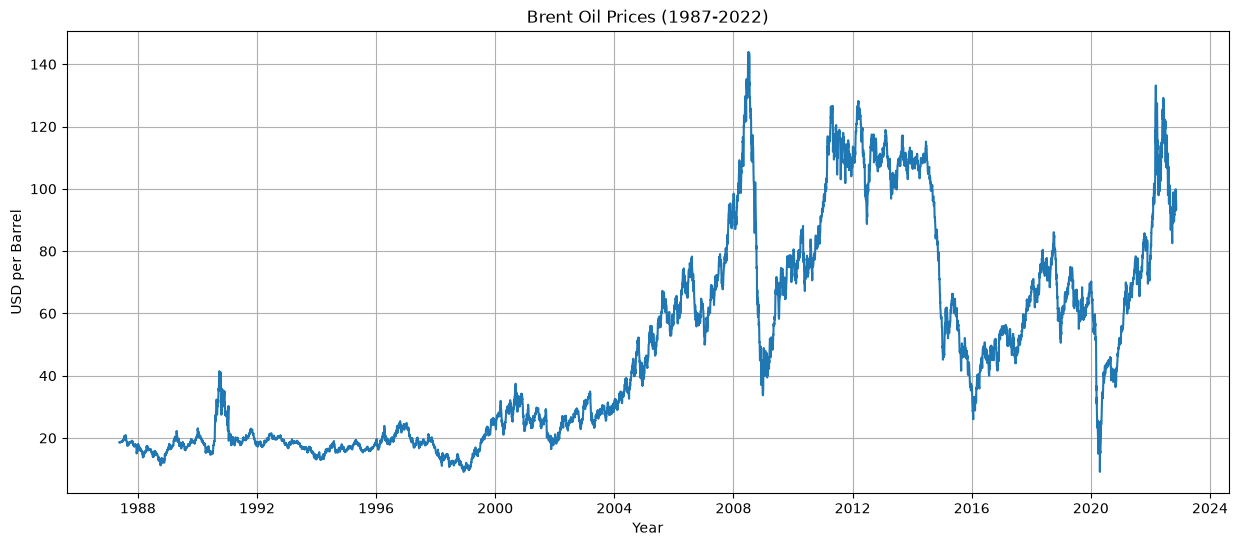

In [10]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Price"])

plt.title("Brent Oil Prices (1987-2022)")

plt.xlabel("Year")

plt.ylabel("USD per Barrel")

plt.grid(True)

plt.show()

### Trend Analysis

The Brent oil price series exhibits clear long-term trends and multiple structural changes over the study period.

Several pronounced price spikes and sharp declines are visible, reflecting periods of geopolitical instability, financial crises, supply disruptions, and global economic shocks. Notable periods include the rapid price increase before the 2008 financial crisis, the sharp decline during the crisis, the collapse in prices during the COVID-19 pandemic in 2020, and the surge following the Russia–Ukraine conflict in 2022.

These observations suggest that the price series is unlikely to be stationary and motivate the use of change point analysis to identify structural breaks.

In [11]:
df["Log_Return"] = np.log(df["Price"]).diff()

In [12]:
def adf_test(series):

    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

In [13]:
adf_test(df["Price"])

ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287


### Stationarity Test (Raw Prices)

The Augmented Dickey-Fuller (ADF) test was applied to determine whether the Brent oil price series is stationary.

**Results**

- ADF Statistic = **-1.99**
- p-value = **0.289**

Since the p-value is greater than the 5% significance level, we fail to reject the null hypothesis of a unit root.

This indicates that the Brent oil price series is **non-stationary**, meaning its statistical properties change over time. Consequently, modeling the raw price series directly may violate assumptions of many statistical methods.

In [14]:
adf_test(df["Log_Return"])

ADF Statistic: -16.427113494485894
p-value: 2.4985801611428892e-29


### Stationarity Test (Log Returns)

Daily log returns were calculated to stabilize the series and remove long-term trends.

The ADF test produced the following results:

- ADF Statistic = **-16.43**
- p-value = **2.50 × 10⁻²⁹**

Since the p-value is substantially smaller than 0.05, the null hypothesis of a unit root is rejected.

Therefore, the log return series is **stationary**, making it more appropriate for statistical modeling and volatility analysis.

In [15]:
df["RollingVol"] = (
    df["Log_Return"]
    .rolling(30)
    .std()
)

In [16]:
df["RollingVolatility"] = (
    df["Log_Return"]
    .rolling(window=30)
    .std()
)

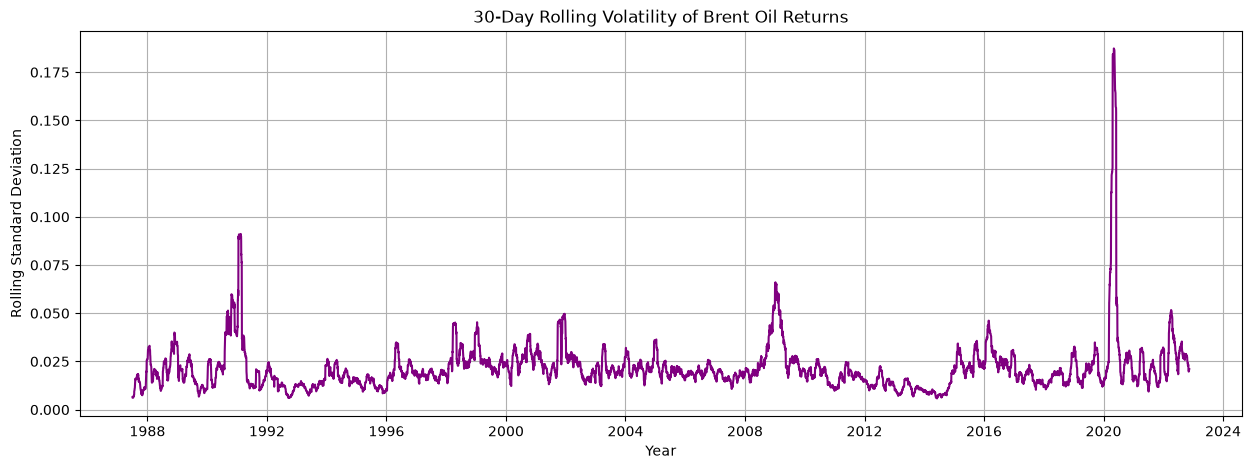

In [24]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["RollingVolatility"],
    color="purple" 
)

plt.title("30-Day Rolling Volatility of Brent Oil Returns")

plt.xlabel("Year")

plt.ylabel("Rolling Standard Deviation")

plt.grid(True)

plt.show()

### Volatility Analysis

The rolling volatility of log returns reveals periods of heightened market uncertainty.

Volatility is not constant throughout the dataset but instead appears in clusters, where periods of relatively calm market behavior are followed by episodes of significant price fluctuations. Such volatility clustering is a common characteristic of financial time series and supports the use of Bayesian change point models to identify structural changes in market behavior.

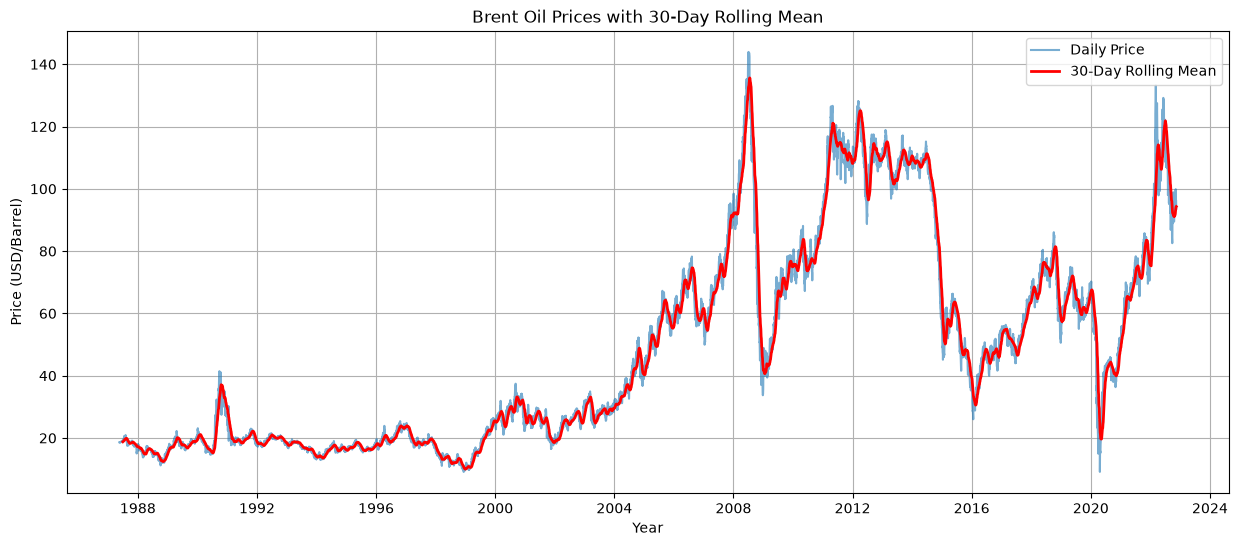

In [22]:
df["RollingMean"] = df["Price"].rolling(window=30).mean()

plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Price"], label="Daily Price", alpha=0.6)

plt.plot(df["Date"], df["RollingMean"],
         color="red",
         linewidth=2,
         label="30-Day Rolling Mean")

plt.title("Brent Oil Prices with 30-Day Rolling Mean")

plt.xlabel("Year")

plt.ylabel("Price (USD/Barrel)")

plt.legend()

plt.grid(True)

plt.show()

### Rolling Mean Analysis

The 30-day rolling mean smooths short-term fluctuations and highlights the underlying trend in Brent oil prices.

The rolling average demonstrates prolonged periods of rising and falling prices, confirming that the mean changes over time rather than remaining constant. This behavior further supports the conclusion that the raw price series is non-stationary.

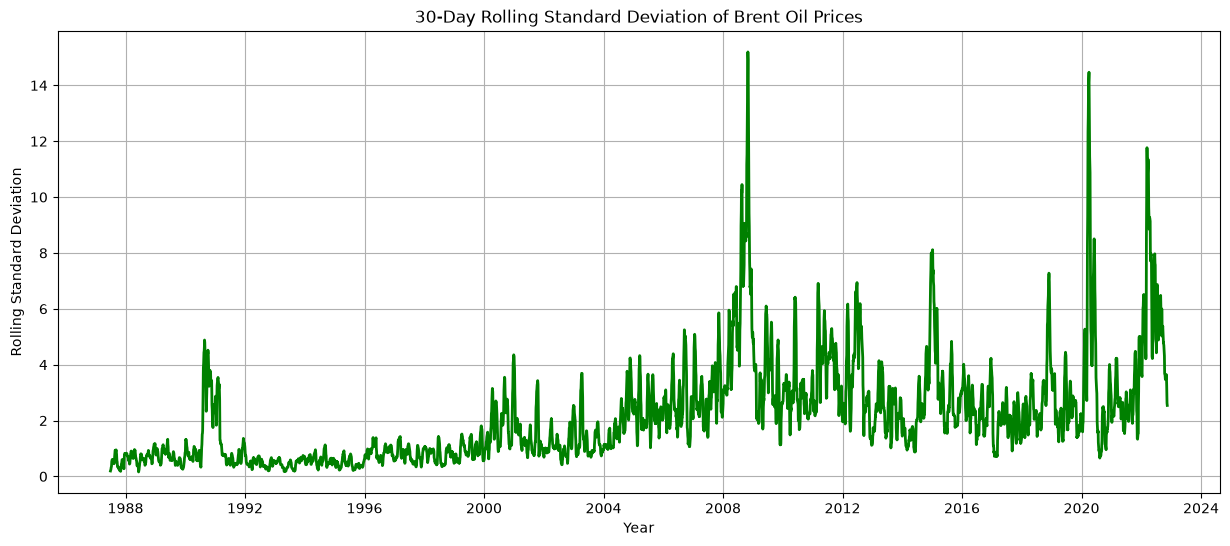

In [23]:
df["RollingSTD"] = df["Price"].rolling(window=30).std()

plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["RollingSTD"],
         color="green",
         linewidth=2)

plt.title("30-Day Rolling Standard Deviation of Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Rolling Standard Deviation")

plt.grid(True)

plt.show()

### Rolling Standard Deviation Analysis

The rolling standard deviation measures how price variability changes over time.

Periods of elevated rolling standard deviation indicate increased market uncertainty and higher volatility, often corresponding to major geopolitical events or economic crises. The changing variability over time suggests that the variance of the series is not constant, another characteristic of non-stationary financial data.

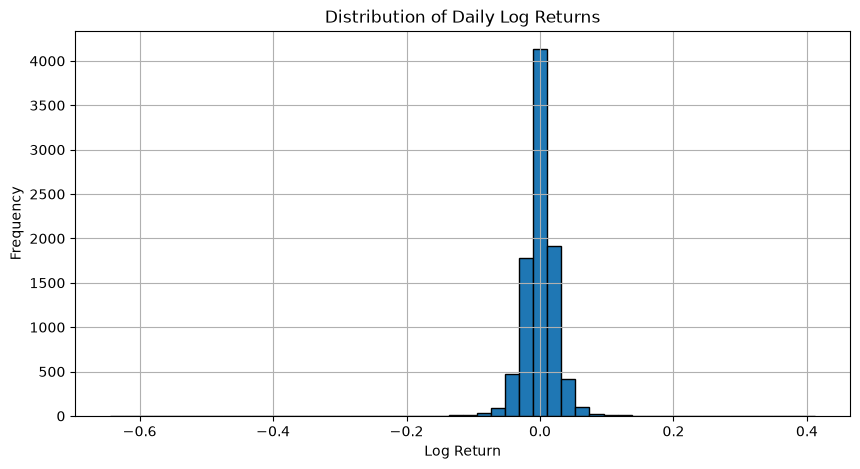

In [25]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Log_Return"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Log Returns")

plt.xlabel("Log Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

### Distribution of Log Returns

The histogram illustrates the distribution of daily log returns.

Most observations are concentrated around zero, indicating that small day-to-day price changes are the most common. However, the presence of observations in both tails suggests occasional extreme price movements associated with major market events.

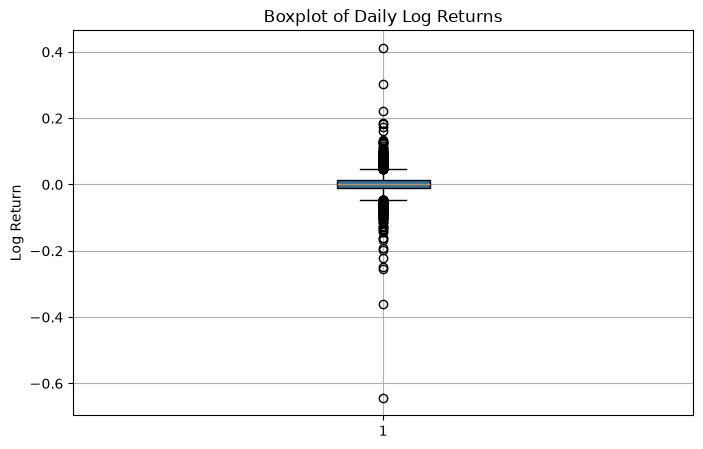

In [26]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["Log_Return"].dropna(),
    vert=True,
    patch_artist=True
)

plt.title("Boxplot of Daily Log Returns")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

### Outlier Analysis

The boxplot reveals several outliers in the daily log return series.

These extreme observations represent unusually large price movements that are uncommon under normal market conditions. Such outliers are expected in financial time series due to unexpected geopolitical events, economic crises, and supply disruptions, reinforcing the need for robust statistical models capable of handling structural breaks.

# Key Exploratory Data Analysis (EDA) Findings

The exploratory analysis of the Brent crude oil price dataset revealed several important characteristics that informed the subsequent modeling approach.

### Data Quality

- The dataset contains **9,011 daily observations** covering the period from **20 May 1987 to 14 November 2022**.
- No missing values or duplicate records were found, indicating that the dataset is complete and suitable for analysis.
- The Date column was successfully converted to datetime format, enabling time series operations.

### Price Behavior

- Brent oil prices ranged from **USD 9.10** to **USD 143.95** per barrel, with an average price of **USD 48.42**.
- The time series exhibits substantial long-term fluctuations, including multiple periods of rapid increases and sharp declines that coincide with major geopolitical and economic events.

### Trend Analysis

- Visual inspection of the price series and the 30-day rolling mean indicates the presence of changing long-term trends rather than a constant average.
- These observations suggest that the price series is non-stationary and contains potential structural breaks.

### Stationarity

- The Augmented Dickey-Fuller (ADF) test showed that the raw Brent oil price series is **non-stationary** (p = 0.289).
- After transforming the data into daily log returns, the ADF test confirmed that the return series is **stationary** (p < 0.001), making it more appropriate for statistical modeling.

### Volatility

- Rolling standard deviation and rolling volatility analyses revealed that market volatility changes over time rather than remaining constant.
- Volatility clustering was observed, where periods of relatively low volatility are followed by periods of heightened market uncertainty.

### Distribution of Returns

- The histogram of log returns shows that most daily price changes are concentrated near zero, while the boxplot identifies several extreme observations.
- These outliers likely correspond to major geopolitical events, financial crises, or significant supply disruptions affecting the global oil market.

### Implications for Modeling

The exploratory analysis indicates that Brent oil prices exhibit non-stationarity, changing volatility, and potential structural breaks. These characteristics support the use of **Bayesian Change Point Analysis**, which is specifically designed to identify statistically significant shifts in the behavior of time series data.